# RAINLINK over the Netherlands, summer 2012

The Dutch commercial microwave link network (Overeem et al. 2024, 4TU) through RAINLINK's
retrieval (Overeem, Leijnse and Uijlenhoet 2016, AMT; pycomlink's port, default
parameters), scored against KNMI's hourly automatic gauges: each path against the gauge
next to it, and IDW maps of all paths at every gauge.

Everything here is read from `results/` and the caches `python src/run.py all` leaves in
`dataset/open_datasets/_netherlands/`; nothing is recomputed.

In [1]:
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr

sys.path.insert(0, str(Path.cwd().parent / "src"))
from core.viz_style import BASELINE, SERIES, use_style
from netherlands import figures, study
from netherlands.settings import RESULTS_DIR

use_style()
C1, C2 = SERIES["stratiform"], SERIES["convective"]
pd.set_option("display.precision", 2)
net = json.loads((RESULTS_DIR / "network.json").read_text())
net

{'period': '2012-06-01 .. 2012-08-31 (interval ends in (2012-06-01 00:00:00, 2012-09-01 00:00:00])',
 'paths_in_data': 2793,
 'sublinks_in_data': 4878,
 'sublinks_usable': 4876,
 'paths_usable': 2791,
 'sublinks_with_rain_estimate_median_per_step': 4418,
 'paths_with_hourly_value_median_per_hour': 2567,
 'wet_fraction_of_estimates': 0.089,
 'knmi_gauges_with_data': 32,
 'grid': '0.02 deg, 141 x 196 cells'}

## The network and the gauges

Summer 2012 has data on every day and ~4000 reporting sub-links per 15 minutes; the network
shrinks from 2013 on (`results/availability_monthly.csv`).

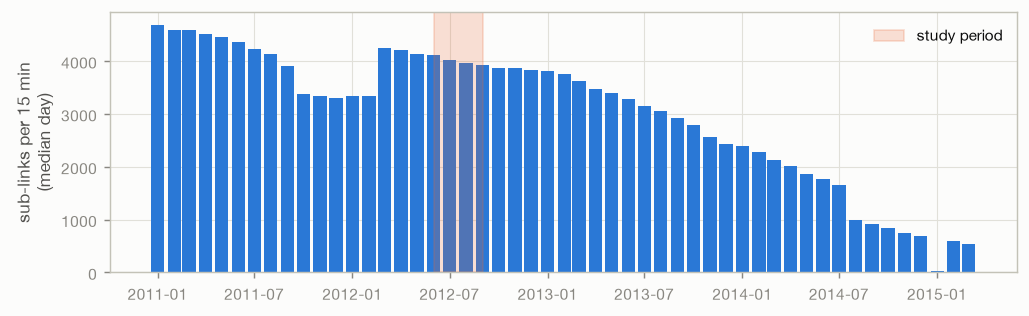

In [2]:
avail = pd.read_csv(RESULTS_DIR / "availability_monthly.csv")
fig, ax = plt.subplots(figsize=(9, 2.6))
ax.bar(pd.to_datetime(avail.month), avail.sublinks_per_step, width=25, color=C1)
ax.axvspan(pd.Timestamp("2012-06-01"), pd.Timestamp("2012-09-01"), color=C2, alpha=0.2, label="study period")
ax.set(ylabel="sub-links per 15 min\n(median day)")
ax.legend(loc="upper right");

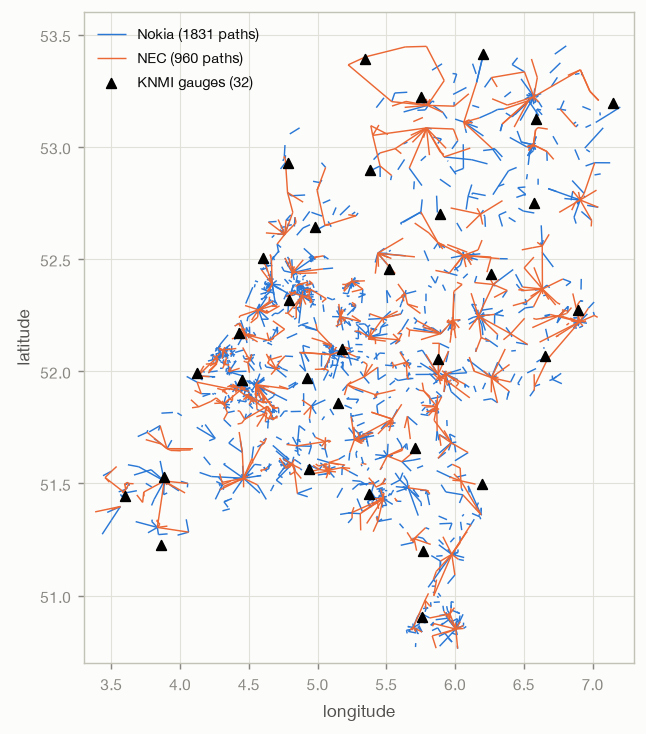

In [3]:
sub = study.retrieve()
links, gauges = study.hourly()
fig, ax = plt.subplots(figsize=(6, 6.5))
figures.plot_network(ax, sub, gauges)

## Path level: each path against the gauge beside it

Paths whose midpoint is within 5 km of a KNMI gauge; hourly totals, and daily totals
over the hours valid in both.

In [4]:
path = pd.read_csv(RESULTS_DIR / "path_level.csv")
pairs = pd.read_csv(RESULTS_DIR / "path_pairs.csv")
path

,pairs_used,scale,pairs,gauges,n,mean_ref,mean_est,rel_bias,nrmse,cv,corr,r2,pod,far,csi
0,all paths,hourly,264,27,546865,0.13,0.17,0.26,11.36,11.35,0.41,0.17,0.53,0.12,0.50
1,all paths,daily,264,27,22491,3.19,3.93,0.23,4.90,4.89,0.38,0.15,0.79,0.05,0.75
2,paths >= 1 km,hourly,205,27,433997,0.13,0.13,-0.02,5.08,5.08,0.63,0.40,0.54,0.13,0.50
3,paths >= 1 km,daily,205,27,17969,3.18,3.08,-0.03,1.59,1.59,0.71,0.50,0.79,0.06,0.75


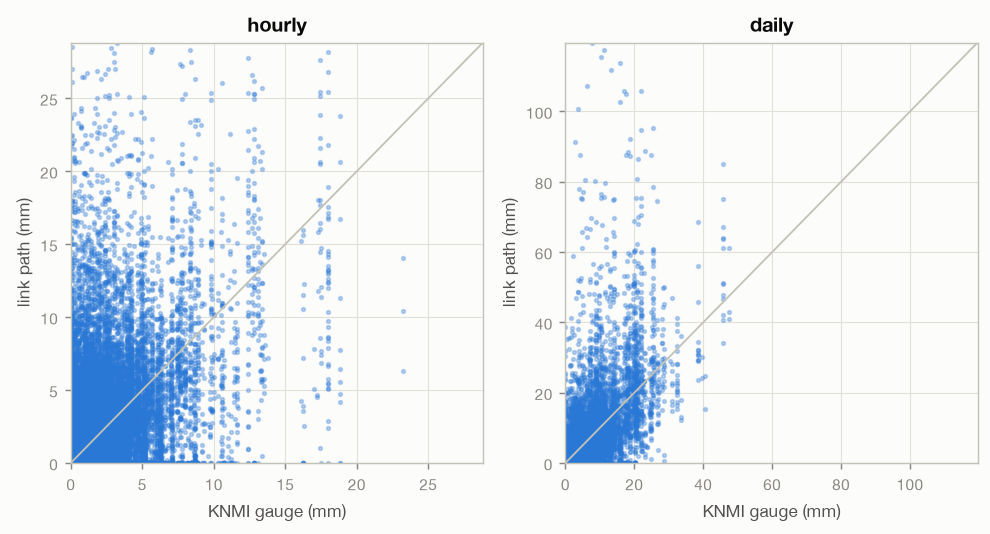

In [5]:
est = links.sel(link=xr.DataArray(pairs.link.values, dims="pair")).drop_vars(
    [c for c in links.coords if c != "time"])
ref = gauges.sel(station=xr.DataArray(pairs.station.values, dims="pair")).drop_vars(
    [c for c in gauges.coords if c != "time"])
est_d, ref_d = study.daily(est, ref)
fig, axes = plt.subplots(1, 2, figsize=(9, 4.2))
for ax, e, r, title in ((axes[0], est, ref, "hourly"), (axes[1], est_d, ref_d, "daily")):
    e, r = e.values.ravel(), r.values.ravel()
    ok = np.isfinite(e) & np.isfinite(r) & ((e > 0) | (r > 0))
    ax.scatter(r[ok], e[ok], s=4, alpha=0.3, color=C1)
    lim = np.nanpercentile(np.r_[e[ok], r[ok]], 99.9)
    ax.plot([0, lim], [0, lim], color=BASELINE, lw=1)
    ax.set(xlim=(0, lim), ylim=(0, lim), xlabel="KNMI gauge (mm)", ylabel="link path (mm)", title=title)

## Map level: IDW of all paths at every gauge

The maps are on a 0.02 deg grid over the country and read at the cell holding each gauge;
the gauges are never used to make them. `masked` sets the map to zero where fewer than
half of the nearby links (distance-weighted) are wet.

In [6]:
maps = pd.read_csv(RESULTS_DIR / "map_level.csv")
maps

,map,scale,gauges_covered,n,mean_ref,mean_est,rel_bias,nrmse,cv,corr,r2,pod,far,csi
0,idw,hourly,31,68448,0.13,0.13,-0.03,3.60,3.60,0.77,0.59,0.67,0.18,0.58
1,idw,daily,31,2852,3.11,3.01,-0.03,1.03,1.03,0.85,0.72,0.87,0.09,0.80
2,masked,hourly,31,68448,0.13,0.11,-0.12,3.71,3.71,0.76,0.57,0.53,0.10,0.50
3,masked,daily,31,2852,3.11,2.75,-0.12,1.06,1.05,0.83,0.70,0.77,0.04,0.74


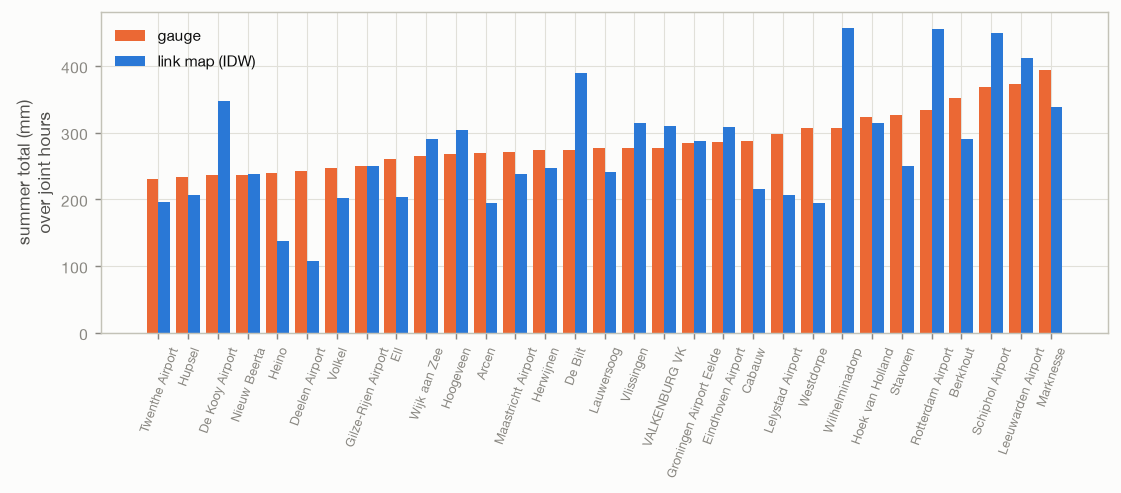

In [7]:
st = pd.read_csv(RESULTS_DIR / "map_stations.csv")
st = st[st["map"] == "idw"].dropna(subset=["corr"]).sort_values("total_gauge")
fig, ax = plt.subplots(figsize=(10, 3.2))
x = np.arange(len(st))
ax.bar(x - 0.2, st.total_gauge, 0.4, color=C2, label="gauge")
ax.bar(x + 0.2, st.total_map, 0.4, color=C1, label="link map (IDW)")
ax.set_xticks(x, st["name"], rotation=70, fontsize=7)
ax.set(ylabel="summer total (mm)\nover joint hours")
ax.legend();

## The wettest day

Daily totals of the link maps, with the gauges drawn on top in the same colours.

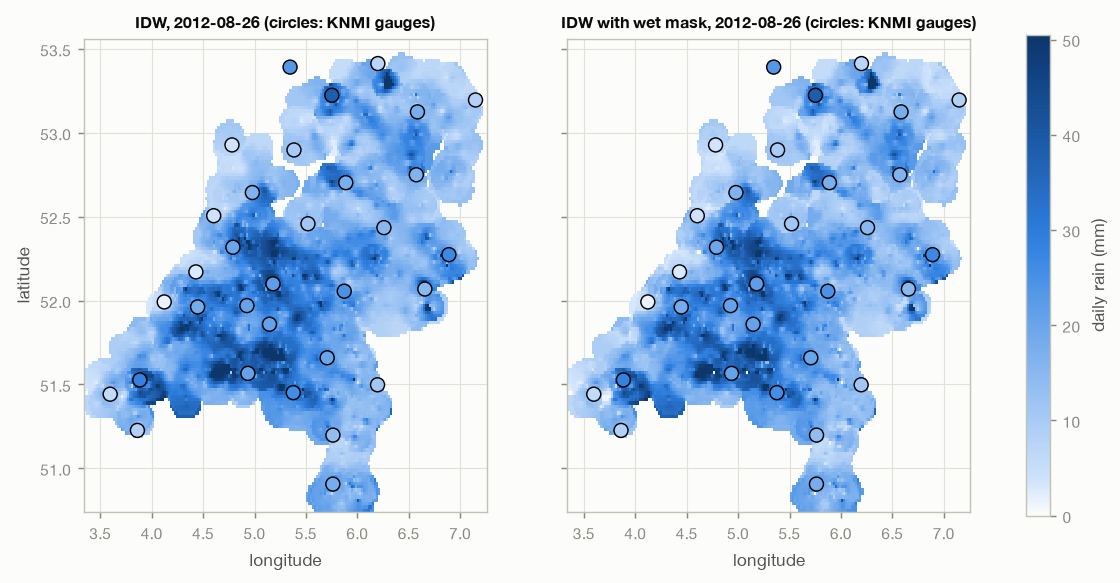

In [8]:
ds = figures.storm_day()
fig, axes = plt.subplots(1, 2, figsize=(11, 6), sharey=True)
figures.plot_storm(axes, ds)

The full tables, and the published RAINLINK numbers they can (loosely) be set against,
are in [`results/report.md`](../results/report.md).